In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/Data.csv")
print(df)

   Country   Age   Salary Purchased
0   France  44.0  72000.0        No
1    Spain  27.0  48000.0       Yes
2  Germany  30.0  54000.0        No
3    Spain  38.0  61000.0        No
4  Germany  40.0      NaN       Yes
5   France  35.0  58000.0       Yes
6    Spain   NaN  52000.0        No
7   France  48.0  79000.0       Yes
8  Germany  50.0  83000.0        No
9   France  37.0  67000.0       Yes


In [6]:
# Map NaN in Age and Salary to each column's minimum (computed ignoring NaN)
mins = df[['Age', 'Salary']].min(skipna=True)
df[['Age', 'Salary']] = df[['Age', 'Salary']].fillna(mins)
print(df[['Age', 'Salary']].head())

    Age   Salary
0  44.0  72000.0
1  27.0  48000.0
2  30.0  54000.0
3  38.0  61000.0
4  40.0  48000.0


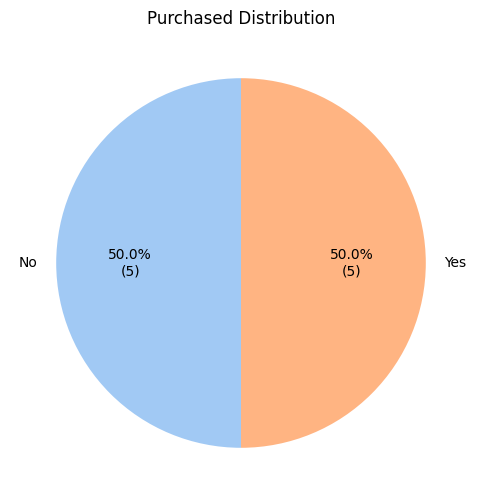

In [7]:
# Metric pie chart cho cot Purchased
purchased_counts = df['Purchased'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    purchased_counts,
    labels=purchased_counts.index,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct / 100 * purchased_counts.sum()))})",
    startangle=90,
    colors=sns.color_palette('pastel', len(purchased_counts)),
)
plt.title('Purchased Distribution')
plt.ylabel('')
plt.show()

In [15]:
X = df[['Country', 'Age', 'Salary']].copy()
y = df['Purchased']

In [16]:
# Mapping text -> number for text columns
codes, uniques = pd.factorize(X['Country'])
X['Country'] = codes
country_mapping = {cat: int(i) for i, cat in enumerate(uniques)}

y = y.map({'No': 0, 'Yes': 1})

print("Country mapping:", country_mapping)
print(X.head())
print(y.head())

Country mapping: {'France': 0, 'Spain': 1, 'Germany': 2}
   Country   Age   Salary
0        0  44.0  72000.0
1        1  27.0  48000.0
2        2  30.0  54000.0
3        1  38.0  61000.0
4        2  40.0  48000.0
0    0
1    1
2    0
3    0
4    1
Name: Purchased, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer

# Normalize feature columns
sc = Normalizer()
X_norm = sc.fit_transform(X[['Country', 'Age', 'Salary']])

# Purchased la target label 0/1, khong normalize target cho bai toan classification
y_norm = y.to_numpy()

print(X_norm)
print(y_norm)

# Data spliting: Training - Test set
x_train, x_test, y_train, y_test = train_test_split(
    X_norm, y_norm, test_size=0.25, random_state=42
)

print("X Train: ", x_train)
print("Y Train: ", y_train)

[[0.00000000e+00 6.11110997e-04 9.99999813e-01]
 [2.08333300e-05 5.62499911e-04 9.99999842e-01]
 [3.70370313e-05 5.55555469e-04 9.99999845e-01]
 [1.63934394e-05 6.22950699e-04 9.99999806e-01]
 [4.16666522e-05 8.33333043e-04 9.99999652e-01]
 [0.00000000e+00 6.03448166e-04 9.99999818e-01]
 [1.92307666e-05 5.19230699e-04 9.99999865e-01]
 [0.00000000e+00 6.07594825e-04 9.99999815e-01]
 [2.40963812e-05 6.02409529e-04 9.99999818e-01]
 [0.00000000e+00 5.52238722e-04 9.99999848e-01]]
[0 1 0 0 1 1 0 1 0 1]
X Train:  [[0.00000000e+00 6.11110997e-04 9.99999813e-01]
 [0.00000000e+00 6.07594825e-04 9.99999815e-01]
 [3.70370313e-05 5.55555469e-04 9.99999845e-01]
 [0.00000000e+00 5.52238722e-04 9.99999848e-01]
 [4.16666522e-05 8.33333043e-04 9.99999652e-01]
 [1.63934394e-05 6.22950699e-04 9.99999806e-01]
 [1.92307666e-05 5.19230699e-04 9.99999865e-01]]
Y Train:  [0 1 0 1 1 0 0]


In [20]:
from sklearn.tree import DecisionTreeRegressor

#Chọn model
dt_model = DecisionTreeRegressor(random_state = 1)

#fit training data into model
dt_model.fit(x_train,y_train)

# test với X_test
Y_predict = dt_model.predict(x_test)
print(Y_predict)
print(y_test)

[0. 0. 1.]
[0 1 1]


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = np.rint(Y_predict).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
conf_mat = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 score:", f1)
print("Confusion matrix:\n", conf_mat)
print("Classification report:\n", report)

Accuracy: 0.6666666666666666
Precision: 1.0
Recall: 0.5
F1 score: 0.6666666666666666
Confusion matrix:
 [[1 0]
 [1 1]]
Classification report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3

